In [1]:
import numpy as np
import matplotlib.pyplot as plt

from math import pi, ceil, log2

from PIL import Image

from tensorflow.keras.datasets import mnist

from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training images:", X_train.shape)
print("Training labels:", y_train.shape)

print("Test images:", X_test.shape)
print("Test labels:", y_test.shape)

Training images: (60000, 28, 28)
Training labels: (60000,)
Test images: (10000, 28, 28)
Test labels: (10000,)


In [3]:
index = 0

image = X_train[index]
label = y_train[index]

print("Label:", label)
print("Image shape:", image.shape)

Label: 5
Image shape: (28, 28)


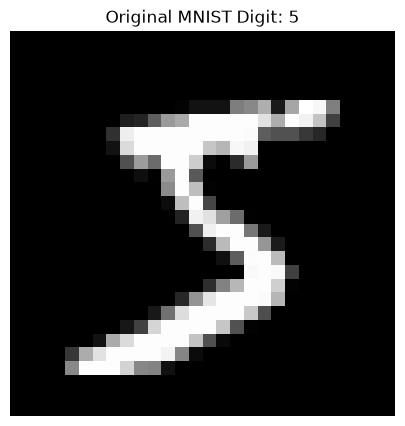

In [4]:
plt.figure(figsize=(5, 5))

plt.imshow(image, cmap="gray")

plt.title(f"Original MNIST Digit: {label}")
plt.axis("off")

plt.show()

In [5]:
small_image = Image.fromarray(image).resize(
    (4, 4),
    Image.Resampling.LANCZOS
)

small_image = np.array(small_image)

print("Resized image shape:", small_image.shape)
print(small_image)

Resized image shape: (4, 4)
[[  0  39  61  20]
 [  0  99  90  10]
 [  3  42 117   4]
 [ 32 103  33   1]]


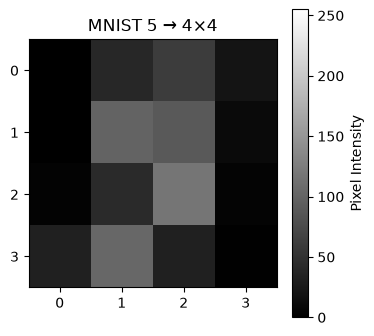

In [6]:
plt.figure(figsize=(4, 4))

plt.imshow(
    small_image,
    cmap="gray",
    vmin=0,
    vmax=255
)

plt.title(f"MNIST {label} → 4×4")
plt.xticks(range(4))
plt.yticks(range(4))
plt.colorbar(label="Pixel Intensity")

plt.show()

In [7]:
theta_values = (small_image / 255.0) * (pi / 2)

print("Pixel values:")
print(small_image)

print("\nTheta values:")
print(theta_values)

Pixel values:
[[  0  39  61  20]
 [  0  99  90  10]
 [  3  42 117   4]
 [ 32 103  33   1]]

Theta values:
[[0.         0.24023944 0.37575912 0.12319971]
 [0.         0.60983857 0.5543987  0.06159986]
 [0.01847996 0.2587194  0.72071831 0.02463994]
 [0.19711954 0.63447852 0.20327952 0.00615999]]


In [8]:
pixels = small_image.flatten()

theta = theta_values.flatten()

print("Number of pixels:", len(pixels))
print("Pixels:")
print(pixels)

print("\nTheta values:")
print(theta)

Number of pixels: 16
Pixels:
[  0  39  61  20   0  99  90  10   3  42 117   4  32 103  33   1]

Theta values:
[0.         0.24023944 0.37575912 0.12319971 0.         0.60983857
 0.5543987  0.06159986 0.01847996 0.2587194  0.72071831 0.02463994
 0.19711954 0.63447852 0.20327952 0.00615999]


In [9]:
image_size = 4

num_pixels = image_size * image_size

num_position_qubits = int(log2(num_pixels))

num_color_qubits = 1

total_qubits = num_position_qubits + num_color_qubits

print("Pixels:", num_pixels)
print("Position qubits:", num_position_qubits)
print("Color qubits:", num_color_qubits)
print("Total qubits:", total_qubits)

Pixels: 16
Position qubits: 4
Color qubits: 1
Total qubits: 5


In [10]:
qc = QuantumCircuit(total_qubits)

position_qubits = list(range(num_position_qubits))
color_qubit = num_position_qubits

print("Position qubits:", position_qubits)
print("Color qubit:", color_qubit)

Position qubits: [0, 1, 2, 3]
Color qubit: 4


In [11]:
for q in position_qubits:
    qc.h(q)

qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=5, num_clbits=0, params=[]), qubits=(<Qubit register=(5, "q"), index=0>, <Qubit register=(5, "q"), index=1>, <Qubit register=(5, "q"), index=2>, <Qubit register=(5, "q"), index=3>, <Qubit register=(5, "q"), index=4>), clbits=())

In [12]:
for position, theta_value in enumerate(theta):

    # Position as 4-bit binary
    binary_position = format(
        position,
        f"0{num_position_qubits}b"
    )

    # Convert zero-controls into one-controls
    for q, bit in enumerate(binary_position):
        if bit == "0":
            qc.x(q)

    # Controlled rotation
    qc.mcry(
        2 * theta_value,
        position_qubits,
        color_qubit
    )

    # Undo X gates
    for q, bit in enumerate(binary_position):
        if bit == "0":
            qc.x(q)

qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=5, num_clbits=0, params=[]), qubits=(<Qubit register=(5, "q"), index=0>, <Qubit register=(5, "q"), index=1>, <Qubit register=(5, "q"), index=2>, <Qubit register=(5, "q"), index=3>, <Qubit register=(5, "q"), index=4>), clbits=())

In [13]:
qc.measure_all()

fig = qc.draw("mpl")
fig.set_size_inches(20, 10)
plt.show()

print(qc)

        ┌───┐ ░ ┌───┐                                             ┌───┐ »
   q_0: ┤ H ├─░─┤ X ├──────────────■─────────────────────■────■───┤ T ├─»
        ├───┤ ░ ├───┤              │             ┌───┐   │  ┌─┴─┐┌┴───┴┐»
   q_1: ┤ H ├─░─┤ X ├──■───────────┼─────────■───┤ T ├───┼──┤ X ├┤ Tdg ├»
        ├───┤ ░ ├───┤  │           │         │   └───┘   │  └───┘└─────┘»
   q_2: ┤ H ├─░─┤ X ├──┼───────────┼─────────┼───────────┼──────────────»
        ├───┤ ░ ├───┤  │           │         │           │              »
   q_3: ┤ H ├─░─┤ X ├──┼───────────┼─────────┼───────────┼──────────────»
        └───┘ ░ ├───┤┌─┴─┐┌─────┐┌─┴─┐┌───┐┌─┴─┐┌─────┐┌─┴─┐┌───┐ ┌───┐ »
   q_4: ──────░─┤ H ├┤ X ├┤ Tdg ├┤ X ├┤ T ├┤ X ├┤ Tdg ├┤ X ├┤ T ├─┤ H ├─»
              ░ └───┘└───┘└─────┘└───┘└───┘└───┘└─────┘└───┘└───┘ └───┘ »
meas: 5/════════════════════════════════════════════════════════════════»
                                                                        »
«                                     

In [14]:
print("Number of qubits:", qc.num_qubits)
print("Depth:", qc.depth())
print("Operations:", qc.count_ops())

Number of qubits: 5
Depth: 706
Operations: OrderedDict({'cx': 384, 't': 256, 'tdg': 192, 'h': 132, 'x': 64, 'ry': 64, 'measure': 5, 'barrier': 3})


In [15]:
aer_sim = Aer.get_backend("aer_simulator")

In [16]:
t_qc = transpile(
    qc,
    aer_sim,
    optimization_level=1
)

print("Original depth:", qc.depth())
print("Transpiled depth:", t_qc.depth())

print("\nOriginal gates:")
print(qc.count_ops())

print("\nTranspiled gates:")
print(t_qc.count_ops())

Original depth: 706
Transpiled depth: 517

Original gates:
OrderedDict({'cx': 384, 't': 256, 'tdg': 192, 'h': 132, 'x': 64, 'ry': 64, 'measure': 5, 'barrier': 3})

Transpiled gates:
OrderedDict({'cx': 384, 'tdg': 192, 't': 192, 'u3': 56, 'x': 30, 'u1': 8, 'h': 5, 'measure': 5, 'barrier': 3})


In [17]:
result = aer_sim.run(
    t_qc,
    shots=4096
).result()

counts = result.get_counts()

print(counts)

{'01001': 253, '01100': 229, '00100': 200, '00000': 290, '01110': 240, '10111': 10, '00010': 273, '00111': 252, '00001': 293, '01111': 216, '01010': 192, '10101': 100, '01011': 143, '00110': 196, '01101': 257, '11011': 87, '10100': 38, '00011': 220, '01000': 244, '10110': 78, '00101': 164, '11010': 83, '11000': 14, '11001': 10, '10011': 9, '11110': 1, '11100': 4}


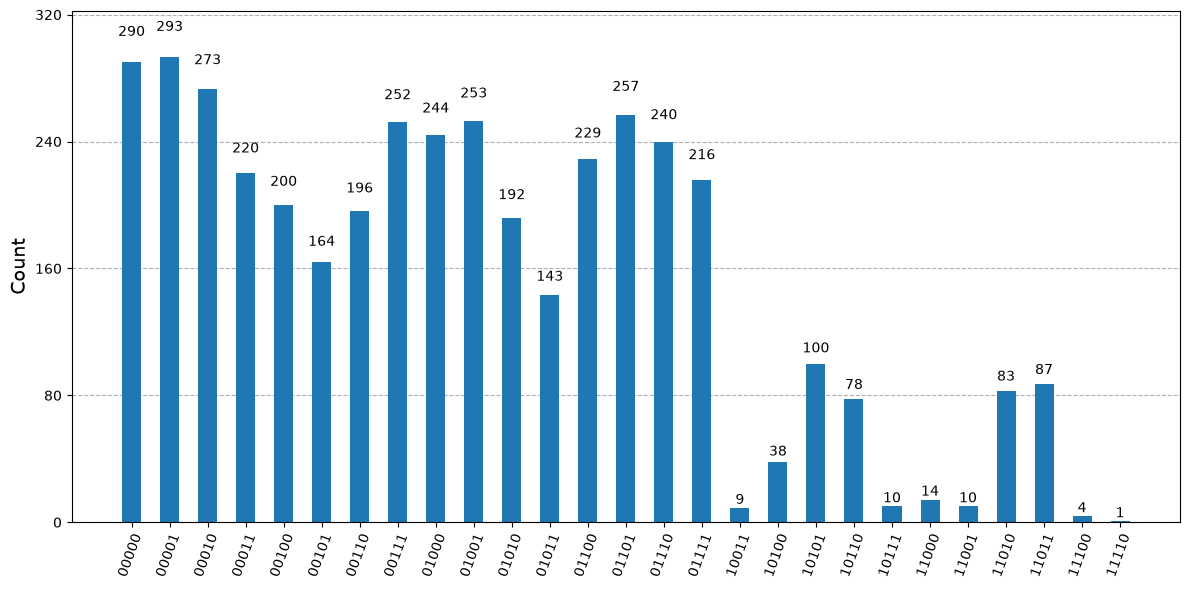

In [18]:
plot_histogram(
    counts,
    figsize=(12, 6)
)

In [19]:
print("Measurement results:")
print()

for state, count in sorted(counts.items()):
    probability = count / 4096

    print(
        f"{state} : "
        f"{count:4d} shots "
        f"({probability:.4f})"
    )

Measurement results:

00000 :  290 shots (0.0708)
00001 :  293 shots (0.0715)
00010 :  273 shots (0.0667)
00011 :  220 shots (0.0537)
00100 :  200 shots (0.0488)
00101 :  164 shots (0.0400)
00110 :  196 shots (0.0479)
00111 :  252 shots (0.0615)
01000 :  244 shots (0.0596)
01001 :  253 shots (0.0618)
01010 :  192 shots (0.0469)
01011 :  143 shots (0.0349)
01100 :  229 shots (0.0559)
01101 :  257 shots (0.0627)
01110 :  240 shots (0.0586)
01111 :  216 shots (0.0527)
10011 :    9 shots (0.0022)
10100 :   38 shots (0.0093)
10101 :  100 shots (0.0244)
10110 :   78 shots (0.0190)
10111 :   10 shots (0.0024)
11000 :   14 shots (0.0034)
11001 :   10 shots (0.0024)
11010 :   83 shots (0.0203)
11011 :   87 shots (0.0212)
11100 :    4 shots (0.0010)
11110 :    1 shots (0.0002)


In [20]:
qc_state = QuantumCircuit(total_qubits)

for q in position_qubits:
    qc_state.h(q)

qc_state.barrier()

for position, theta_value in enumerate(theta):

    binary_position = format(
        position,
        f"0{num_position_qubits}b"
    )

    for q, bit in enumerate(binary_position):
        if bit == "0":
            qc_state.x(q)

    qc_state.mcry(
        2 * theta_value,
        position_qubits,
        color_qubit
    )

    for q, bit in enumerate(binary_position):
        if bit == "0":
            qc_state.x(q)

qc_state.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=5, num_clbits=0, params=[]), qubits=(<Qubit register=(5, "q"), index=0>, <Qubit register=(5, "q"), index=1>, <Qubit register=(5, "q"), index=2>, <Qubit register=(5, "q"), index=3>, <Qubit register=(5, "q"), index=4>), clbits=())

In [21]:
state_sim = Aer.get_backend("statevector_simulator")

state_result = state_sim.run(qc_state).result()

statevector = state_result.get_statevector()

print(statevector)

Statevector([2.50000000e-01-1.30662668e-15j,
             2.49957313e-01-1.27013644e-15j,
             2.50000000e-01-1.20896513e-15j,
             2.45158693e-01-1.33060963e-15j,
             2.32557327e-01-7.77155196e-16j,
             1.87832972e-01-1.33164627e-15j,
             2.12554284e-01-1.05424044e-15j,
             2.44852442e-01-1.52767686e-15j,
             2.42820258e-01-1.11101246e-15j,
             2.41679601e-01-1.51363881e-15j,
             2.04935121e-01-9.56882328e-16j,
             2.01345230e-01-1.44324548e-15j,
             2.48105127e-01-1.18074327e-15j,
             2.49924113e-01-1.20876863e-15j,
             2.49525832e-01-1.08424670e-15j,
             2.49995257e-01-1.23694109e-15j,
             7.49970919e-16+1.15745310e-15j,
             4.61972624e-03+1.03623332e-15j,
             6.33744583e-16+1.09816433e-15j,
             4.89613668e-02+7.72989328e-16j,
             9.17446979e-02-1.19681715e-18j,
             1.64981134e-01-4.04507056e-16j,
          

In [22]:
reconstructed = np.zeros(num_pixels)

for position in range(num_pixels):

    binary_position = format(
        position,
        f"0{num_position_qubits}b"
    )

    # Qiskit's statevector indexing uses little-endian ordering
    position_bits = binary_position[::-1]

    index_0 = int(
        "0" + position_bits,
        2
    )

    index_1 = int(
        "1" + position_bits,
        2
    )

    p1 = abs(statevector[index_1]) ** 2

    theta_recovered = np.arcsin(
        np.sqrt(min(1, p1))
    )

    pixel_value = (
        theta_recovered / (pi / 2)
    ) * 255

    reconstructed[position] = pixel_value

In [23]:
reconstructed_image = reconstructed.reshape(
    image_size,
    image_size
)

reconstructed_image = np.clip(
    reconstructed_image,
    0,
    255
)

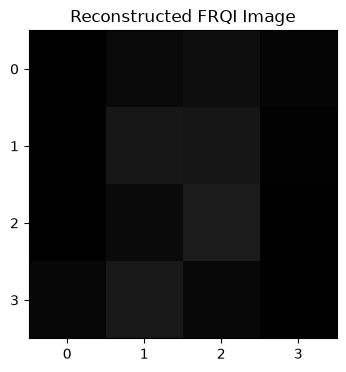

In [24]:
plt.figure(figsize=(4, 4))

plt.imshow(
    reconstructed_image,
    cmap="gray",
    vmin=0,
    vmax=255
)

plt.title("Reconstructed FRQI Image")
plt.xticks(range(4))
plt.yticks(range(4))

plt.show()

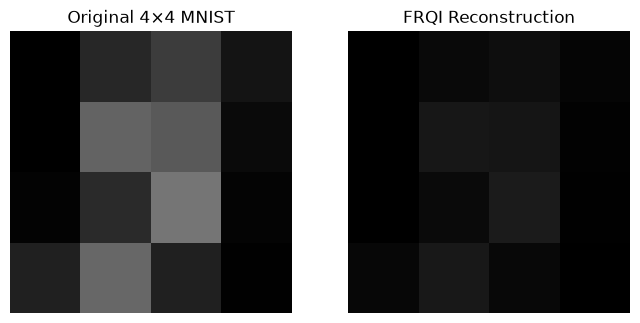

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(
    small_image,
    cmap="gray",
    vmin=0,
    vmax=255
)

axes[0].set_title("Original 4×4 MNIST")

axes[1].imshow(
    reconstructed_image,
    cmap="gray",
    vmin=0,
    vmax=255
)

axes[1].set_title("FRQI Reconstruction")

for ax in axes:
    ax.axis("off")

plt.show()

In [26]:
mse = np.mean(
    (small_image.astype(float) - reconstructed_image) ** 2
)

print("Mean Squared Error:", mse)

Mean Squared Error: 1889.8464120245208


In [27]:
print("===== FRQI MNIST BENCHMARK =====")

print("Image size:", f"{image_size}x{image_size}")

print("Number of pixels:", num_pixels)

print("Position qubits:", num_position_qubits)

print("Color qubits:", num_color_qubits)

print("Total qubits:", total_qubits)

print("Circuit depth:", qc_state.depth())

print("Gate counts:")
print(qc_state.count_ops())

===== FRQI MNIST BENCHMARK =====
Image size: 4x4
Number of pixels: 16
Position qubits: 4
Color qubits: 1
Total qubits: 5
Circuit depth: 705
Gate counts:
OrderedDict({'cx': 384, 't': 256, 'tdg': 192, 'h': 132, 'x': 64, 'ry': 64, 'barrier': 2})


In [28]:
from qiskit_ibm_runtime.fake_provider import FakeAthensV2

fake_athens = FakeAthensV2()

In [29]:
optimized_qc = transpile(
    qc_state,
    backend=fake_athens,
    seed_transpiler=11,
    optimization_level=3
)

In [30]:
print("===== BEFORE TRANSPILATION =====")

print("Depth:", qc_state.depth())
print("Gates:", qc_state.count_ops())

print()

print("===== AFTER TRANSPILATION =====")

print("Depth:", optimized_qc.depth())
print("Gates:", optimized_qc.count_ops())

===== BEFORE TRANSPILATION =====
Depth: 705
Gates: OrderedDict({'cx': 384, 't': 256, 'tdg': 192, 'h': 132, 'x': 64, 'ry': 64, 'barrier': 2})

===== AFTER TRANSPILATION =====
Depth: 1231
Gates: OrderedDict({'rz': 824, 'cx': 639, 'sx': 363, 'x': 101, 'barrier': 2})


In [31]:
image_size = 8

print("New image size:", image_size, "x", image_size)

New image size: 8 x 8


In [32]:
small_image = Image.fromarray(image).resize(
    (image_size, image_size),
    Image.Resampling.LANCZOS
)

small_image = np.array(small_image)

print("Resized image shape:", small_image.shape)
print(small_image)

Resized image shape: (8, 8)
[[  0   0   0   0   0   0   0   0]
 [  0   0  28  61 108 108  80   0]
 [  2   0 120 233 154  77  25   1]
 [  0   2   0 119  64   0   0   0]
 [  0   3   3   0 146 123   1   2]
 [  0   0   0  81 187 147   0   3]
 [  0  66 174 185  70   0   1   0]
 [  0  43  50   0   0   1   0   0]]


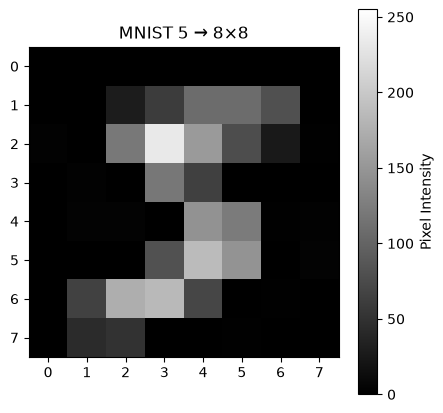

In [33]:
plt.figure(figsize=(5, 5))

plt.imshow(
    small_image,
    cmap="gray",
    vmin=0,
    vmax=255
)

plt.title(f"MNIST {label} → 8×8")
plt.xticks(range(8))
plt.yticks(range(8))
plt.colorbar(label="Pixel Intensity")

plt.show()

In [34]:
theta_values = (small_image / 255.0) * (pi / 2)

print("Theta shape:", theta_values.shape)
print(theta_values)

Theta shape: (8, 8)
[[0.         0.         0.         0.         0.         0.
  0.         0.        ]
 [0.         0.         0.1724796  0.37575912 0.66527844 0.66527844
  0.49279885 0.        ]
 [0.01231997 0.         0.73919827 1.43527664 0.94863778 0.47431889
  0.15399964 0.00615999]
 [0.         0.01231997 0.         0.73303829 0.39423908 0.
  0.         0.        ]
 [0.         0.01847996 0.01847996 0.         0.8993579  0.75767823
  0.00615999 0.01231997]
 [0.         0.         0.         0.49895883 1.15191731 0.90551788
  0.         0.01847996]
 [0.         0.40655905 1.07183749 1.13959734 0.43119899 0.
  0.00615999 0.        ]
 [0.         0.26487938 0.30799928 0.         0.         0.00615999
  0.         0.        ]]


In [35]:
pixels = small_image.flatten()
theta = theta_values.flatten()

print("Number of pixels:", len(pixels))
print("Number of theta values:", len(theta))

Number of pixels: 64
Number of theta values: 64


In [36]:
num_pixels = image_size * image_size

num_position_qubits = int(log2(num_pixels))

num_color_qubits = 1

total_qubits = num_position_qubits + num_color_qubits

print("Pixels:", num_pixels)
print("Position qubits:", num_position_qubits)
print("Color qubits:", num_color_qubits)
print("Total qubits:", total_qubits)

Pixels: 64
Position qubits: 6
Color qubits: 1
Total qubits: 7


In [37]:
qc_8x8 = QuantumCircuit(total_qubits)

position_qubits = list(range(num_position_qubits))
color_qubit = num_position_qubits

print("Position qubits:", position_qubits)
print("Color qubit:", color_qubit)

Position qubits: [0, 1, 2, 3, 4, 5]
Color qubit: 6


In [38]:
for q in position_qubits:
    qc_8x8.h(q)

qc_8x8.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=7, num_clbits=0, params=[]), qubits=(<Qubit register=(7, "q"), index=0>, <Qubit register=(7, "q"), index=1>, <Qubit register=(7, "q"), index=2>, <Qubit register=(7, "q"), index=3>, <Qubit register=(7, "q"), index=4>, <Qubit register=(7, "q"), index=5>, <Qubit register=(7, "q"), index=6>), clbits=())

In [39]:
for position, theta_value in enumerate(theta):

    binary_position = format(
        position,
        f"0{num_position_qubits}b"
    )

    # Convert 0-controls into 1-controls
    for q, bit in enumerate(binary_position):
        if bit == "0":
            qc_8x8.x(q)

    # Controlled rotation
    qc_8x8.mcry(
        2 * theta_value,
        position_qubits,
        color_qubit
    )

    # Undo X gates
    for q, bit in enumerate(binary_position):
        if bit == "0":
            qc_8x8.x(q)

qc_8x8.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=7, num_clbits=0, params=[]), qubits=(<Qubit register=(7, "q"), index=0>, <Qubit register=(7, "q"), index=1>, <Qubit register=(7, "q"), index=2>, <Qubit register=(7, "q"), index=3>, <Qubit register=(7, "q"), index=4>, <Qubit register=(7, "q"), index=5>, <Qubit register=(7, "q"), index=6>), clbits=())

In [40]:
print("Qubits:", qc_8x8.num_qubits)
print("Depth:", qc_8x8.depth())
print("Operations:", qc_8x8.count_ops())

Qubits: 7
Depth: 4875
Operations: OrderedDict({'p': 3840, 'cx': 3584, 'h': 518, 'x': 384, 'ry': 256, 'barrier': 2})


In [41]:
fig = qc_8x8.draw("mpl")
fig.set_size_inches(25, 12)
plt.show()

In [42]:
qc_8x8.draw("text")

┌───┐ ░ ┌───┐┌────────┐                                          »
q_0: ┤ H ├─░─┤ X ├┤ P(π/8) ├──■───────────────■────────────────────■──»
     ├───┤ ░ ├───┤├────────┤┌─┴─┐┌─────────┐┌─┴─┐                  │  »
q_1: ┤ H ├─░─┤ X ├┤ P(π/8) ├┤ X ├┤ P(-π/8) ├┤ X ├──■───────────────┼──»
     ├───┤ ░ ├───┤├────────┤└───┘└─────────┘└───┘┌─┴─┐┌─────────┐┌─┴─┐»
q_2: ┤ H ├─░─┤ X ├┤ P(π/8) ├─────────────────────┤ X ├┤ P(-π/8) ├┤ X ├»
     ├───┤ ░ ├───┤├────────┤                     └───┘└─────────┘└───┘»
q_3: ┤ H ├─░─┤ X ├┤ P(π/8) ├──■───────────────■────────────────────■──»
     ├───┤ ░ ├───┤├────────┤┌─┴─┐┌─────────┐┌─┴─┐                  │  »
q_4: ┤ H ├─░─┤ X ├┤ P(π/8) ├┤ X ├┤ P(-π/8) ├┤ X ├──■───────────────┼──»
     ├───┤ ░ ├───┤├────────┤└───┘└─────────┘└───┘┌─┴─┐┌─────────┐┌─┴─┐»
q_5: ┤ H ├─░─┤ X ├┤ P(π/8) ├─────────────────────┤ X ├┤ P(-π/8) ├┤ X ├»
     └───┘ ░ ├───┤├────────┤                     └───┘└─────────┘└───┘»
q_6: ──────░─┤ H ├┤ P(π/8) ├──────────────────────────────────────────»
           ░ └───┘└────────┘                                          »
«                                                                        »
«q_0: ────────────────────────────■──────────────────────────────────────»
«                                 │                                      »
«q_1: ────────────■───────────────┼────────────────────■─────────────────»
«     ┌────────┐┌─┴─┐┌─────────┐┌─┴─┐                  │                 »
«q_2: ┤ P(π/8) ├┤ X ├┤ P(-π/8) ├┤ X ├──■───────────────┼──────────────■──»
«     └────────┘└───┘└─────────┘└───┘  │               │              │  »
«q_3: ────────────────────────────■────┼───────────────┼──────────────┼──»
«                                 │    │               │              │  »
«q_4: ────────────■───────────────┼────┼───────────────┼──────────────┼──»
«     ┌────────┐┌─┴─┐┌─────────┐┌─┴─┐  │               │              │  »
«q_5: ┤ P(π/8) ├┤ X ├┤ P(-π/8) ├┤ X ├──┼───────────────┼──────────────┼──»
«     └────────┘└───┘└─────────┘└───┘┌─┴─┐┌─────────┐┌─┴─┐┌────────┐┌─┴─┐»
«q_6: ───────────────────────────────┤ X ├┤ P(-π/8) ├┤ X ├┤ P(π/8) ├┤ X ├»
«                                    └───┘└─────────┘└───┘└────────┘└───┘»
«                                                                              »
«q_0: ─────────────■───────────────────────────────────────────────────────────»
«                  │                                 ┌────────┐                »
«q_1: ─────────────┼──────────────────────────────■──┤ P(π/8) ├────────────────»
«                  │                              │  └────────┘      ┌────────┐»
«q_2: ─────────────┼──────────────■───────────────┼──────────────■───┤ P(π/8) ├»
«                  │              │               │              │   └────────┘»
«q_3: ─────────────┼──────────────┼───────────────┼──────────────┼─────────────»
«                  │              │               │              │             »
«q_4: ─────────────┼──────────────┼───────────────┼──────────────┼─────────────»
«                  │              │               │              │             »
«q_5: ─────────────┼──────────────┼───────────────┼──────────────┼─────────────»
«     ┌─────────┐┌─┴─┐┌────────┐┌─┴─┐┌─────────┐┌─┴─┐┌────────┐┌─┴─┐┌─────────┐»
«q_6: ┤ P(-π/8) ├┤ X ├┤ P(π/8) ├┤ X ├┤ P(-π/8) ├┤ X ├┤ P(π/8) ├┤ X ├┤ P(-π/8) ├»
«     └─────────┘└───┘└────────┘└───┘└─────────┘└───┘└────────┘└───┘└─────────┘»
«          ┌────────┐                                                   »
«q_0: ──■──┤ P(π/8) ├────■───────────────────■───────────────────────■──»
«       │  └────────┘  ┌─┴─┐  ┌─────────┐  ┌─┴─┐                     │  »
«q_1: ──┼──────────────┤ X ├──┤ P(-π/8) ├──┤ X ├─────■───────────────┼──»
«       │              └───┘  └─────────┘  └───┘   ┌─┴─┐┌─────────┐┌─┴─┐»
«q_2: ──┼──────────────────────────────────────────┤ X ├┤ P(-π/8) ├┤ X ├»
«       │                                          └───┘└─────────┘└───┘»
«q_3: ──┼──────────────────────────────────────────────────────────

In [43]:
qc_8x8_measure = qc_8x8.copy()

qc_8x8_measure.measure_all()

In [44]:
aer_sim = Aer.get_backend("aer_simulator")

In [45]:
t_qc_8x8 = transpile(
    qc_8x8_measure,
    aer_sim,
    optimization_level=1
)

print("Original depth:", qc_8x8_measure.depth())
print("Transpiled depth:", t_qc_8x8.depth())

print("\nOriginal gates:")
print(qc_8x8_measure.count_ops())

print("\nTranspiled gates:")
print(t_qc_8x8.count_ops())

Original depth: 4876
Transpiled depth: 4109

Original gates:
OrderedDict({'p': 3840, 'cx': 3584, 'h': 518, 'x': 384, 'ry': 256, 'measure': 7, 'barrier': 3})

Transpiled gates:
OrderedDict({'cx': 3584, 'p': 3458, 'u3': 258, 'u1': 123, 'measure': 7, 'h': 6, 'barrier': 3, 'u2': 2})


In [46]:
result = aer_sim.run(
    t_qc_8x8,
    shots=4096
).result()

counts = result.get_counts()

print(counts)

{'0010101': 57, '0000010': 60, '1001101': 49, '0111110': 70, '0100010': 67, '0001011': 51, '0011010': 67, '0100011': 52, '0111101': 69, '0001100': 44, '0011011': 61, '0110001': 63, '0101111': 69, '0000110': 70, '0010100': 75, '0100001': 53, '0111111': 73, '0001010': 18, '1110010': 72, '0100110': 79, '0111010': 79, '0001111': 64, '0010111': 55, '0111001': 69, '0101001': 26, '0000101': 69, '0110010': 2, '0101110': 84, '0011001': 70, '0101101': 32, '0110011': 7, '0000100': 59, '1010011': 47, '0100111': 59, '1110100': 9, '1001010': 39, '0111100': 47, '0100100': 57, '0101000': 55, '0111011': 61, '0100101': 57, '0001110': 51, '0011101': 59, '0110110': 32, '0101010': 47, '0111000': 63, '1001001': 44, '0100000': 73, '0011100': 55, '1010010': 28, '0011111': 67, '0010000': 68, '0000000': 64, '0110111': 53, '0011000': 59, '1101101': 27, '0010001': 62, '0000011': 71, '0110100': 58, '0101100': 45, '0000111': 59, '0110000': 64, '1101001': 36, '0001001': 28, '0010011': 14, '0011110': 60, '0010110': 6

In [47]:
import matplotlib.pyplot as plt
from qiskit.visualization import plot_histogram

print("Number of measured states:", len(counts))
print("Total shots:", sum(counts.values()))

fig = plot_histogram(counts)
fig.set_size_inches(16, 8)

plt.show()

Number of measured states: 88
Total shots: 4096


In [48]:
from qiskit_ibm_runtime.fake_provider import FakeNairobiV2

fake_backend = FakeNairobiV2()

print("Number of qubits:", fake_backend.num_qubits)

Number of qubits: 7


In [49]:
optimized_8x8 = transpile(
    qc_8x8_measure,
    backend=fake_backend,
    seed_transpiler=11,
    optimization_level=3
)

print("===== 8×8 FRQI =====")

print("\nBEFORE TRANSPILATION")
print("Depth:", qc_8x8_measure.depth())
print("Gates:", qc_8x8_measure.count_ops())

print("\nAFTER TRANSPILATION")
print("Depth:", optimized_8x8.depth())
print("Gates:", optimized_8x8.count_ops())

===== 8×8 FRQI =====

BEFORE TRANSPILATION
Depth: 4876
Gates: OrderedDict({'p': 3840, 'cx': 3584, 'h': 518, 'x': 384, 'ry': 256, 'measure': 7, 'barrier': 3})

AFTER TRANSPILATION
Depth: 7878
Gates: OrderedDict({'cx': 5756, 'rz': 5715, 'sx': 2058, 'x': 314, 'measure': 7, 'barrier': 3})


In [50]:
result_hw = aer_sim.run(
    optimized_8x8,
    shots=4096
).result()

counts_hw = result_hw.get_counts()

print(counts_hw)

{'0101111': 74, '0110001': 55, '0000110': 65, '0000100': 61, '0110011': 8, '0101101': 20, '0000011': 69, '0101100': 48, '0110100': 51, '0110010': 1, '0101110': 65, '0000101': 71, '0011000': 62, '0111111': 67, '0100001': 63, '0001010': 27, '1110010': 64, '0100100': 71, '0111100': 47, '1001011': 14, '1001100': 26, '1110110': 32, '0001110': 62, '0100101': 58, '0111011': 66, '0111000': 58, '1110100': 6, '1001010': 35, '0100111': 54, '0010101': 53, '0011101': 62, '0110000': 67, '1101100': 17, '0010110': 57, '0011100': 52, '1101001': 37, '0000010': 64, '0010000': 73, '0001000': 59, '0001111': 72, '0100110': 73, '0111010': 60, '1110101': 16, '0110111': 66, '0000000': 67, '0110110': 45, '0101010': 46, '0000001': 70, '0111001': 57, '0011010': 67, '0001100': 28, '0100011': 50, '0111101': 50, '0101000': 58, '0100010': 62, '0111110': 65, '1001101': 49, '0001011': 50, '0011110': 72, '0100000': 61, '0010100': 77, '0010010': 37, '0011001': 64, '0011011': 62, '0011111': 72, '0010111': 58, '0010001': 7

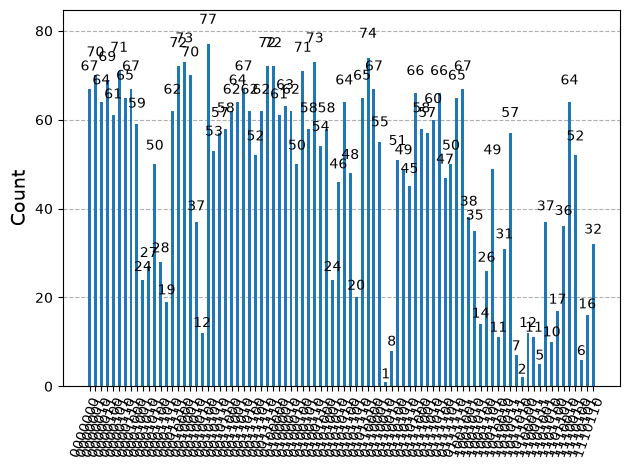

In [51]:
plot_histogram(counts_hw)

In [52]:
depth_increase = (
    optimized_8x8.depth() /
    qc_8x8_measure.depth() - 1
) * 100

print(
    f"\nDepth increase: {depth_increase:.2f}%"
)


Depth increase: 61.57%


In [53]:
benchmark_8x8 = {
    "image_size": "8x8",
    "pixels": 64,
    "position_qubits": 6,
    "intensity_qubits": 1,
    "total_qubits": 7,

    "original_depth": 4876,
    "transpiled_depth": 7878,

    "original_cx": 3584,
    "transpiled_cx": 5756,

    "depth_increase_percent": 61.57
}

print(benchmark_8x8)

{'image_size': '8x8', 'pixels': 64, 'position_qubits': 6, 'intensity_qubits': 1, 'total_qubits': 7, 'original_depth': 4876, 'transpiled_depth': 7878, 'original_cx': 3584, 'transpiled_cx': 5756, 'depth_increase_percent': 61.57}


In [54]:
cx_increase = (
    (5756 - 3584) / 3584
) * 100

print(f"CX increase: {cx_increase:.2f}%")

CX increase: 60.60%


In [55]:
qc_8x8_state = qc_8x8.copy()

In [56]:
state_sim = Aer.get_backend("statevector_simulator")

state_result = state_sim.run(
    qc_8x8_state
).result()

statevector = np.asarray(
    state_result.get_statevector()
)

print("Statevector dimension:", len(statevector))

Statevector dimension: 128


In [57]:
from math import asin, sqrt, pi

reconstructed = np.zeros(64)

for position in range(64):

    position_bits = format(position, "06b")

    # Qiskit uses little-endian ordering.
    # Reverse the position bits for statevector indexing.
    reversed_position = position_bits[::-1]

    # Color qubit = 1
    index_1 = int(
        "1" + reversed_position,
        2
    )

    amplitude = statevector[index_1]

    p1 = abs(amplitude) ** 2

    theta_recovered = asin(
        sqrt(min(1.0, p1 * 64))
    )

    pixel = (
        theta_recovered / (pi / 2)
    ) * 255

    reconstructed[position] = pixel

reconstructed = reconstructed.reshape(8, 8)

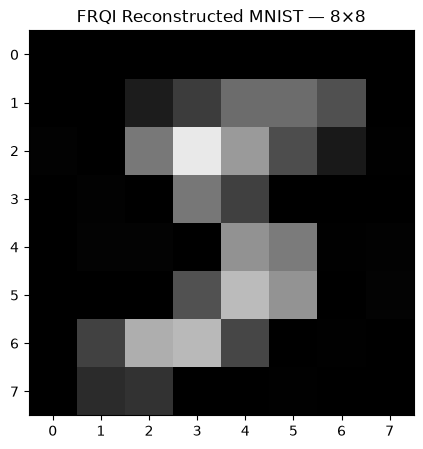

In [58]:
plt.figure(figsize=(5, 5))

plt.imshow(
    reconstructed,
    cmap="gray",
    vmin=0,
    vmax=255
)

plt.title("FRQI Reconstructed MNIST — 8×8")
plt.xticks(range(8))
plt.yticks(range(8))

plt.show()

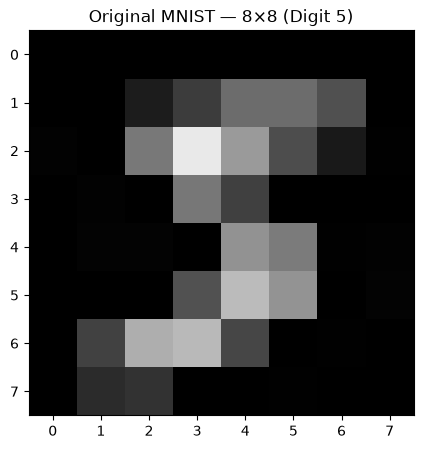

In [59]:
plt.figure(figsize=(5, 5))

plt.imshow(
    small_image,
    cmap="gray",
    vmin=0,
    vmax=255
)

plt.title(f"Original MNIST — 8×8 (Digit {label})")
plt.xticks(range(8))
plt.yticks(range(8))

plt.show()

In [60]:
mse = np.mean(
    (
        small_image.astype(float)
        - reconstructed
    ) ** 2
)

print(f"MSE: {mse:.6f}")

MSE: 0.000000


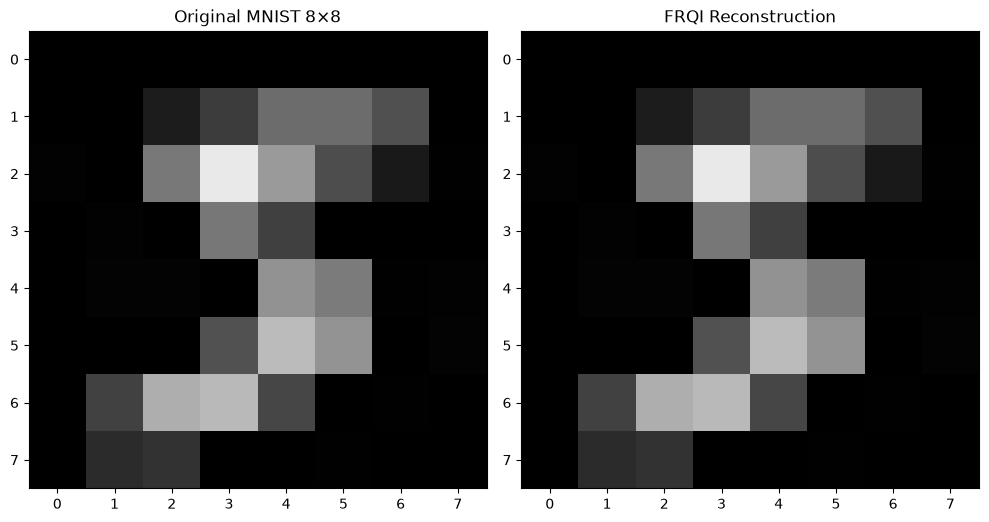

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(
    small_image,
    cmap="gray",
    vmin=0,
    vmax=255
)

axes[0].set_title("Original MNIST 8×8")

axes[1].imshow(
    reconstructed,
    cmap="gray",
    vmin=0,
    vmax=255
)

axes[1].set_title("FRQI Reconstruction")

for ax in axes:
    ax.set_xticks(range(8))
    ax.set_yticks(range(8))

plt.tight_layout()
plt.show()

In [62]:
mse = np.mean(
    (
        small_image.astype(float)
        - reconstructed
    ) ** 2
)

if mse == 0:
    psnr = float("inf")
else:
    psnr = 10 * np.log10(
        (255 ** 2) / mse
    )

print("MSE :", mse)
print("PSNR:", psnr, "dB")

MSE : 1.9873984508415933e-24
PSNR: 285.1479541391216 dB


In [63]:
image_size = 16

print("New image size:", image_size, "x", image_size)

New image size: 16 x 16


In [64]:
small_image_16 = Image.fromarray(image).resize(
    (image_size, image_size),
    Image.Resampling.LANCZOS
)

small_image_16 = np.array(small_image_16)

print("Image shape:", small_image_16.shape)

Image shape: (16, 16)


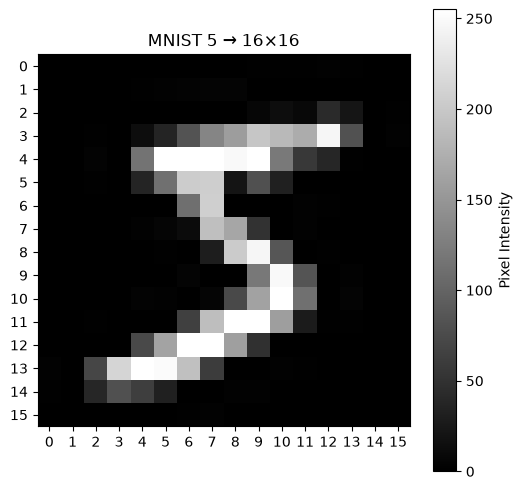

In [65]:
plt.figure(figsize=(6, 6))

plt.imshow(
    small_image_16,
    cmap="gray",
    vmin=0,
    vmax=255
)

plt.title(f"MNIST {label} → 16×16")
plt.xticks(range(16))
plt.yticks(range(16))
plt.colorbar(label="Pixel Intensity")

plt.show()

In [66]:
theta_values_16 = (
    small_image_16 / 255.0
) * (pi / 2)

print("Theta shape:", theta_values_16.shape)

Theta shape: (16, 16)


In [67]:
pixels_16 = small_image_16.flatten()
theta_16 = theta_values_16.flatten()

print("Number of pixels:", len(pixels_16))
print("Number of theta values:", len(theta_16))

Number of pixels: 256
Number of theta values: 256


In [68]:
num_pixels_16 = image_size * image_size

num_position_qubits_16 = int(
    log2(num_pixels_16)
)

num_color_qubits_16 = 1

total_qubits_16 = (
    num_position_qubits_16
    + num_color_qubits_16
)

print("Pixels:", num_pixels_16)
print("Position qubits:", num_position_qubits_16)
print("Color qubits:", num_color_qubits_16)
print("Total qubits:", total_qubits_16)

Pixels: 256
Position qubits: 8
Color qubits: 1
Total qubits: 9


In [69]:
qc_16x16 = QuantumCircuit(total_qubits_16)

position_qubits_16 = list(
    range(num_position_qubits_16)
)

color_qubit_16 = num_position_qubits_16

print("Position qubits:", position_qubits_16)
print("Color qubit:", color_qubit_16)

Position qubits: [0, 1, 2, 3, 4, 5, 6, 7]
Color qubit: 8


In [70]:
for q in position_qubits_16:
    qc_16x16.h(q)

qc_16x16.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=9, num_clbits=0, params=[]), qubits=(<Qubit register=(9, "q"), index=0>, <Qubit register=(9, "q"), index=1>, <Qubit register=(9, "q"), index=2>, <Qubit register=(9, "q"), index=3>, <Qubit register=(9, "q"), index=4>, <Qubit register=(9, "q"), index=5>, <Qubit register=(9, "q"), index=6>, <Qubit register=(9, "q"), index=7>, <Qubit register=(9, "q"), index=8>), clbits=())

In [71]:
for position, theta_value in enumerate(theta_16):

    binary_position = format(
        position,
        f"0{num_position_qubits_16}b"
    )

    # Convert zero-controls to one-controls
    for q, bit in enumerate(binary_position):
        if bit == "0":
            qc_16x16.x(q)

    # Encode pixel intensity
    qc_16x16.mcry(
        2 * theta_value,
        position_qubits_16,
        color_qubit_16
    )

    # Undo X gates
    for q, bit in enumerate(binary_position):
        if bit == "0":
            qc_16x16.x(q)

qc_16x16.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=9, num_clbits=0, params=[]), qubits=(<Qubit register=(9, "q"), index=0>, <Qubit register=(9, "q"), index=1>, <Qubit register=(9, "q"), index=2>, <Qubit register=(9, "q"), index=3>, <Qubit register=(9, "q"), index=4>, <Qubit register=(9, "q"), index=5>, <Qubit register=(9, "q"), index=6>, <Qubit register=(9, "q"), index=7>, <Qubit register=(9, "q"), index=8>), clbits=())

In [72]:
print("===== 16×16 FRQI =====")

print("Qubits:", qc_16x16.num_qubits)
print("Depth:", qc_16x16.depth())
print("Operations:", qc_16x16.count_ops())

===== 16×16 FRQI =====
Qubits: 9
Depth: 50435
Operations: OrderedDict({'cx': 26624, 't': 16384, 'tdg': 14336, 'h': 12296, 'x': 2048, 'ry': 1024, 'barrier': 2})


In [73]:
qc_16x16_measure = qc_16x16.copy()

qc_16x16_measure.measure_all()

In [74]:
aer_sim = Aer.get_backend("aer_simulator")

In [75]:
t_qc_16x16 = transpile(
    qc_16x16_measure,
    aer_sim,
    optimization_level=1
)

print("===== 16×16 TRANSPILATION =====")

print("Original depth:",
      qc_16x16_measure.depth())

print("Transpiled depth:",
      t_qc_16x16.depth())

print("\nOriginal gates:")
print(qc_16x16_measure.count_ops())

print("\nTranspiled gates:")
print(t_qc_16x16.count_ops())

===== 16×16 TRANSPILATION =====
Original depth: 50436
Transpiled depth: 43013

Original gates:
OrderedDict({'cx': 26624, 't': 16384, 'tdg': 14336, 'h': 12296, 'x': 2048, 'ry': 1024, 'measure': 9, 'barrier': 3})

Transpiled gates:
OrderedDict({'cx': 26624, 't': 11264, 'tdg': 10240, 'u2': 8193, 'u1': 583, 'x': 495, 'u3': 440, 'h': 9, 'measure': 9, 'barrier': 3})


In [76]:
print("===== FRQI SCALING: 8×8 → 16×16 =====")

print("Pixel increase:",
      256 / 64, "x")

print("Depth increase:",
      50435 / 4876, "x")

print("CX increase:",
      26624 / 3584, "x")

print("RY increase:",
      1024 / 256, "x")

===== FRQI SCALING: 8×8 → 16×16 =====
Pixel increase: 4.0 x
Depth increase: 10.343519278096801 x
CX increase: 7.428571428571429 x
RY increase: 4.0 x


In [77]:
depth_pct = (
    (50435 - 4876) / 4876
) * 100

cx_pct = (
    (26624 - 3584) / 3584
) * 100

print(f"Depth increase: {depth_pct:.2f}%")
print(f"CX increase: {cx_pct:.2f}%")

Depth increase: 934.35%
CX increase: 642.86%


In [78]:
benchmark_16x16 = {
    "image_size": "16x16",
    "pixels": 256,
    "position_qubits": 8,
    "intensity_qubits": 1,
    "total_qubits": 9,

    "depth": qc_16x16.depth(),

    "cx": qc_16x16.count_ops().get("cx", 0),
    "ry": qc_16x16.count_ops().get("ry", 0),
    "x": qc_16x16.count_ops().get("x", 0),
    "h": qc_16x16.count_ops().get("h", 0),
    "t": qc_16x16.count_ops().get("t", 0),
    "tdg": qc_16x16.count_ops().get("tdg", 0),
}

print(benchmark_16x16)

{'image_size': '16x16', 'pixels': 256, 'position_qubits': 8, 'intensity_qubits': 1, 'total_qubits': 9, 'depth': 50435, 'cx': 26624, 'ry': 1024, 'x': 2048, 'h': 12296, 't': 16384, 'tdg': 14336}


In [79]:
import qiskit_ibm_runtime.fake_provider as fp

candidates = []

for name in dir(fp):
    if name.startswith("Fake"):
        backend_class = getattr(fp, name)

        try:
            backend = backend_class()

            if hasattr(backend, "num_qubits") and backend.num_qubits >= 9:
                candidates.append((name, backend.num_qubits))

        except Exception:
            pass

for name, qubits in candidates:
    print(f"{name}: {qubits} qubits")

C:\Users\sripo\.conda\envs\ai_ml\Lib\site-packages\qiskit_ibm_runtime\fake_provider\backends\nighthawk\fake_nighthawk.py:78: UserWarning: Properties of fake_nighthawk are not intended to represent typical nighthawk error values.
  warnings.warn(


FakeAachen: 156 qubits
FakeAlgiers: 27 qubits
FakeAlmadenV2: 20 qubits
FakeAuckland: 27 qubits
FakeBerlin: 120 qubits
FakeBoeblingenV2: 20 qubits
FakeBoston: 156 qubits
FakeBrisbane: 127 qubits
FakeBrooklynV2: 65 qubits
FakeBrussels: 127 qubits
FakeCairoV2: 27 qubits
FakeCambridgeV2: 28 qubits
FakeCusco: 127 qubits
FakeFez: 156 qubits
FakeGeneva: 27 qubits
FakeGuadalupeV2: 16 qubits
FakeHanoiV2: 27 qubits
FakeJohannesburgV2: 20 qubits
FakeKawasaki: 127 qubits
FakeKingston: 156 qubits
FakeKolkataV2: 27 qubits
FakeKyiv: 127 qubits
FakeKyoto: 127 qubits
FakeManhattanV2: 65 qubits
FakeMarrakesh: 156 qubits
FakeMelbourneV2: 15 qubits
FakeMiami: 120 qubits
FakeMontrealV2: 27 qubits
FakeMumbaiV2: 27 qubits
FakeNighthawk: 120 qubits
FakeOsaka: 127 qubits
FakeParisV2: 27 qubits
FakePeekskill: 27 qubits
FakePittsburgh: 156 qubits
FakePoughkeepsieV2: 20 qubits
FakePrague: 33 qubits
FakeQuebec: 127 qubits
FakeRochesterV2: 53 qubits
FakeSherbrooke: 127 qubits
FakeSingaporeV2: 20 qubits
FakeStrasbou

In [80]:
from qiskit_ibm_runtime.fake_provider import FakeGuadalupeV2

fake_16 = FakeGuadalupeV2()

print("Backend:", fake_16.name)
print("Qubits:", fake_16.num_qubits)

Backend: fake_guadalupe
Qubits: 16


In [81]:
optimized_16x16 = transpile(
    qc_16x16_measure,
    backend=fake_16,
    seed_transpiler=11,
    optimization_level=3
)

In [82]:
print("===== 16×16 FRQI =====")

print("\nBEFORE TRANSPILATION")
print("Depth:", qc_16x16_measure.depth())
print("Gates:", qc_16x16_measure.count_ops())

print("\nAFTER TRANSPILATION")
print("Depth:", optimized_16x16.depth())
print("Gates:", optimized_16x16.count_ops())

===== 16×16 FRQI =====

BEFORE TRANSPILATION
Depth: 50436
Gates: OrderedDict({'cx': 26624, 't': 16384, 'tdg': 14336, 'h': 12296, 'x': 2048, 'ry': 1024, 'measure': 9, 'barrier': 3})

AFTER TRANSPILATION
Depth: 83450
Gates: OrderedDict({'rz': 54323, 'cx': 46851, 'sx': 22933, 'x': 2725, 'measure': 9, 'barrier': 3})


In [83]:
original_depth_16 = qc_16x16_measure.depth()
transpiled_depth_16 = optimized_16x16.depth()

original_cx_16 = qc_16x16_measure.count_ops().get("cx", 0)
transpiled_cx_16 = optimized_16x16.count_ops().get("cx", 0)

depth_increase_16 = (
    (transpiled_depth_16 - original_depth_16)
    / original_depth_16
) * 100

cx_increase_16 = (
    (transpiled_cx_16 - original_cx_16)
    / original_cx_16
) * 100

print(f"Depth increase: {depth_increase_16:.2f}%")
print(f"CX increase: {cx_increase_16:.2f}%")

Depth increase: 65.46%
CX increase: 75.97%


In [84]:
benchmark_16x16 = {
    "resolution": "16x16",
    "pixels": 256,
    "position_qubits": 8,
    "total_qubits": 9,

    "original_depth": qc_16x16.depth(),
    "transpiled_depth": optimized_16x16.depth(),

    "original_cx": qc_16x16.count_ops().get("cx", 0),
    "transpiled_cx": optimized_16x16.count_ops().get("cx", 0),

    "depth_overhead_percent": depth_increase_16,
    "cx_overhead_percent": cx_increase_16
}

benchmark_16x16

{'resolution': '16x16',
 'pixels': 256,
 'position_qubits': 8,
 'total_qubits': 9,
 'original_depth': 50435,
 'transpiled_depth': 83450,
 'original_cx': 26624,
 'transpiled_cx': 46851,
 'depth_overhead_percent': 65.45721310175271,
 'cx_overhead_percent': 75.97280649038461}

In [85]:
from qiskit_ibm_runtime.fake_provider import FakeGuadalupeV2

common_backend = FakeGuadalupeV2()

print("Backend:", common_backend.name)
print("Available qubits:", common_backend.num_qubits)

Backend: fake_guadalupe
Available qubits: 16


In [86]:
optimized_4x4_common = transpile(
    qc,
    backend=common_backend,
    seed_transpiler=11,
    optimization_level=3
)

print("===== 4×4 ON COMMON BACKEND =====")

print("Original depth:", qc.depth())
print("Transpiled depth:", optimized_4x4_common.depth())

print("Original gates:", qc.count_ops())
print("Transpiled gates:", optimized_4x4_common.count_ops())

===== 4×4 ON COMMON BACKEND =====
Original depth: 706
Transpiled depth: 1159
Original gates: OrderedDict({'cx': 384, 't': 256, 'tdg': 192, 'h': 132, 'x': 64, 'ry': 64, 'measure': 5, 'barrier': 3})
Transpiled gates: OrderedDict({'cx': 696, 'rz': 632, 'sx': 228, 'x': 36, 'measure': 5, 'barrier': 3})


In [87]:
optimized_8x8_common = transpile(
    qc_8x8,
    backend=common_backend,
    seed_transpiler=11,
    optimization_level=3
)

print("===== 8×8 ON COMMON BACKEND =====")

print("Original depth:", qc_8x8.depth())
print("Transpiled depth:", optimized_8x8_common.depth())

print("Original gates:", qc_8x8.count_ops())
print("Transpiled gates:", optimized_8x8_common.count_ops())

===== 8×8 ON COMMON BACKEND =====
Original depth: 4875
Transpiled depth: 8869
Original gates: OrderedDict({'p': 3840, 'cx': 3584, 'h': 518, 'x': 384, 'ry': 256, 'barrier': 2})
Transpiled gates: OrderedDict({'cx': 6237, 'rz': 5950, 'sx': 1924, 'x': 505, 'barrier': 2})


In [88]:
optimized_16x16_common = transpile(
    qc_16x16,
    backend=common_backend,
    seed_transpiler=11,
    optimization_level=3
)

print("===== 8×8 ON COMMON BACKEND =====")
print("Original depth:", qc_8x8_measure.depth())
print("Transpiled depth:", optimized_8x8_common.depth())

print("Original gates:", qc_8x8_measure.count_ops())
print("Transpiled gates:", optimized_8x8_common.count_ops())

===== 8×8 ON COMMON BACKEND =====
Original depth: 4876
Transpiled depth: 8869
Original gates: OrderedDict({'p': 3840, 'cx': 3584, 'h': 518, 'x': 384, 'ry': 256, 'measure': 7, 'barrier': 3})
Transpiled gates: OrderedDict({'cx': 6237, 'rz': 5950, 'sx': 1924, 'x': 505, 'barrier': 2})


In [89]:
optimized_16x16_common = transpile(
    qc_16x16_measure,
    backend=common_backend,
    seed_transpiler=11,
    optimization_level=3
)

print("===== 16×16 ON COMMON BACKEND =====")
print("Original depth:", qc_16x16_measure.depth())
print("Transpiled depth:", optimized_16x16_common.depth())

print("Original gates:", qc_16x16_measure.count_ops())
print("Transpiled gates:", optimized_16x16_common.count_ops())

===== 16×16 ON COMMON BACKEND =====
Original depth: 50436
Transpiled depth: 83450
Original gates: OrderedDict({'cx': 26624, 't': 16384, 'tdg': 14336, 'h': 12296, 'x': 2048, 'ry': 1024, 'measure': 9, 'barrier': 3})
Transpiled gates: OrderedDict({'rz': 54323, 'cx': 46851, 'sx': 22933, 'x': 2725, 'measure': 9, 'barrier': 3})


In [90]:
def calculate_overhead(original, transpiled):
    
    original_depth = original.depth()
    transpiled_depth = transpiled.depth()

    original_cx = original.count_ops().get("cx", 0)
    transpiled_cx = transpiled.count_ops().get("cx", 0)

    depth_overhead = (
        (transpiled_depth - original_depth)
        / original_depth
    ) * 100

    cx_overhead = (
        (transpiled_cx - original_cx)
        / original_cx
    ) * 100

    return {
        "Original Depth": original_depth,
        "Transpiled Depth": transpiled_depth,
        "Original CX": original_cx,
        "Transpiled CX": transpiled_cx,
        "Depth Overhead (%)": depth_overhead,
        "CX Overhead (%)": cx_overhead
    }

In [91]:
results_4x4 = calculate_overhead(
    qc,
    optimized_qc
)

results_8x8 = calculate_overhead(
    qc_8x8,
    optimized_8x8_common
)

results_16x16 = calculate_overhead(
    qc_16x16,
    optimized_16x16_common
)

print("4×4:", results_4x4)
print("8×8:", results_8x8)
print("16×16:", results_16x16)

4×4: {'Original Depth': 706, 'Transpiled Depth': 1231, 'Original CX': 384, 'Transpiled CX': 639, 'Depth Overhead (%)': 74.36260623229461, 'CX Overhead (%)': 66.40625}
8×8: {'Original Depth': 4875, 'Transpiled Depth': 8869, 'Original CX': 3584, 'Transpiled CX': 6237, 'Depth Overhead (%)': 81.92820512820512, 'CX Overhead (%)': 74.0234375}
16×16: {'Original Depth': 50435, 'Transpiled Depth': 83450, 'Original CX': 26624, 'Transpiled CX': 46851, 'Depth Overhead (%)': 65.46049370476852, 'CX Overhead (%)': 75.97280649038461}


In [92]:
import pandas as pd

benchmark_common = pd.DataFrame([
    {
        "Resolution": "4×4",
        "Pixels": 16,
        "Qubits": 5,
        **results_4x4
    },
    {
        "Resolution": "8×8",
        "Pixels": 64,
        "Qubits": 7,
        **results_8x8
    },
    {
        "Resolution": "16×16",
        "Pixels": 256,
        "Qubits": 9,
        **results_16x16
    }
])

benchmark_common

,Resolution,Pixels,Qubits,Original Depth,Transpiled Depth,Original CX,Transpiled CX,Depth Overhead (%),CX Overhead (%)
0,4×4,16,5,706,1231,384,639,74.362606,66.406250
1,8×8,64,7,4875,8869,3584,6237,81.928205,74.023438
2,16×16,256,9,50435,83450,26624,46851,65.460494,75.972806


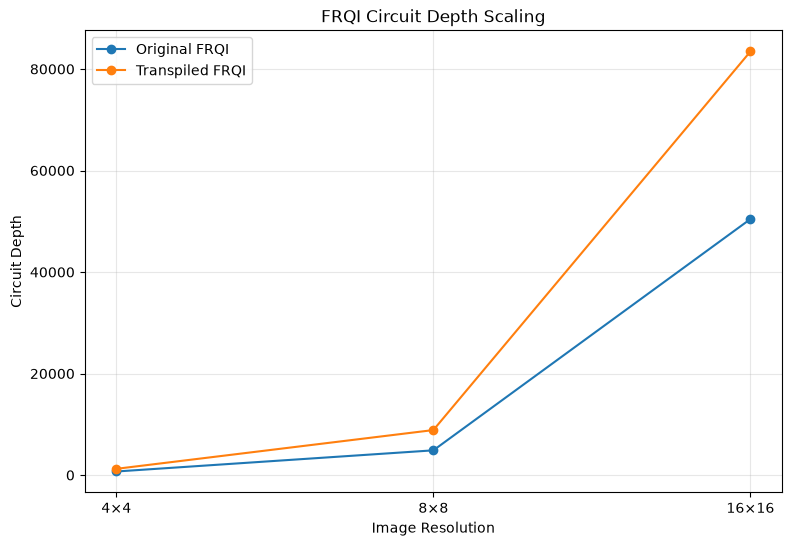

In [93]:
import matplotlib.pyplot as plt

resolutions = ["4×4", "8×8", "16×16"]
original_depth = [706, 4875, 50435]
transpiled_depth = [1231, 8869, 83450]

plt.figure(figsize=(9, 6))

plt.plot(
    resolutions,
    original_depth,
    marker="o",
    label="Original FRQI"
)

plt.plot(
    resolutions,
    transpiled_depth,
    marker="o",
    label="Transpiled FRQI"
)

plt.xlabel("Image Resolution")
plt.ylabel("Circuit Depth")
plt.title("FRQI Circuit Depth Scaling")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

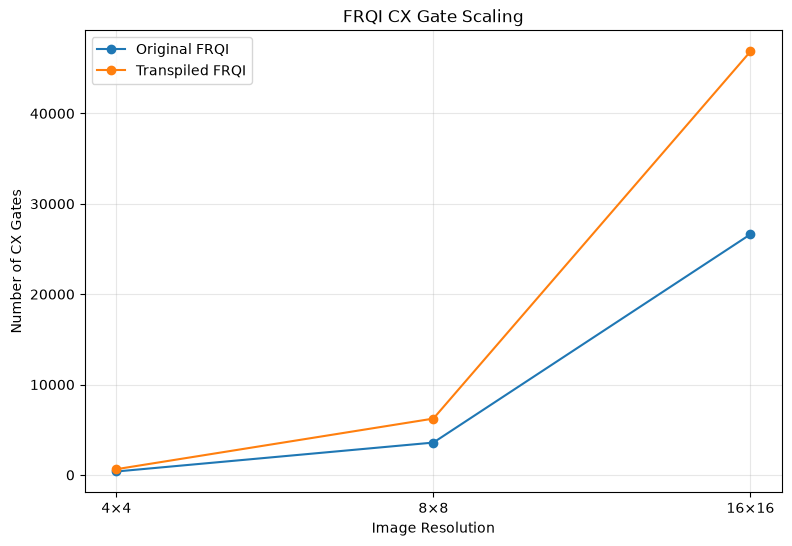

In [94]:
original_cx = [384, 3584, 26624]
transpiled_cx = [639, 6237, 46851]

plt.figure(figsize=(9, 6))

plt.plot(
    resolutions,
    original_cx,
    marker="o",
    label="Original FRQI"
)

plt.plot(
    resolutions,
    transpiled_cx,
    marker="o",
    label="Transpiled FRQI"
)

plt.xlabel("Image Resolution")
plt.ylabel("Number of CX Gates")
plt.title("FRQI CX Gate Scaling")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

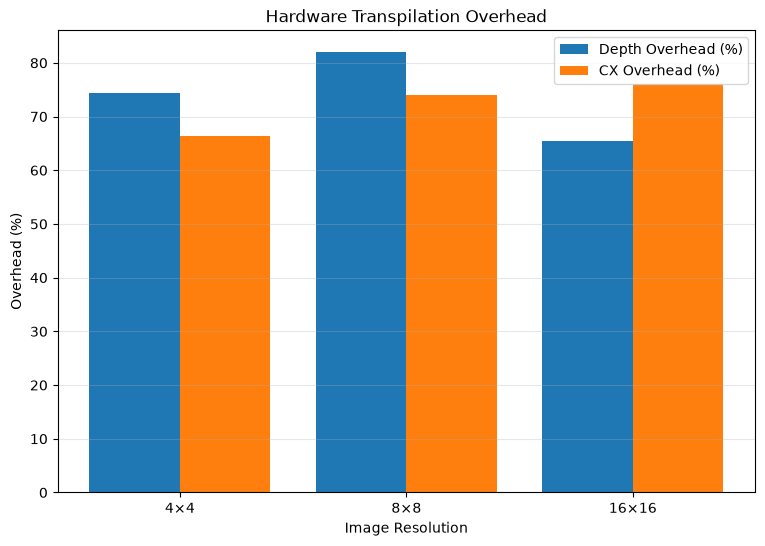

In [95]:
depth_overhead = [74.362606, 81.928205, 65.460494]
cx_overhead = [66.406250, 74.023438, 75.972806]

plt.figure(figsize=(9, 6))

x = range(len(resolutions))

plt.bar(
    [i - 0.2 for i in x],
    depth_overhead,
    width=0.4,
    label="Depth Overhead (%)"
)

plt.bar(
    [i + 0.2 for i in x],
    cx_overhead,
    width=0.4,
    label="CX Overhead (%)"
)

plt.xticks(list(x), resolutions)
plt.xlabel("Image Resolution")
plt.ylabel("Overhead (%)")
plt.title("Hardware Transpilation Overhead")
plt.legend()
plt.grid(True, axis="y", alpha=0.3)

plt.show()

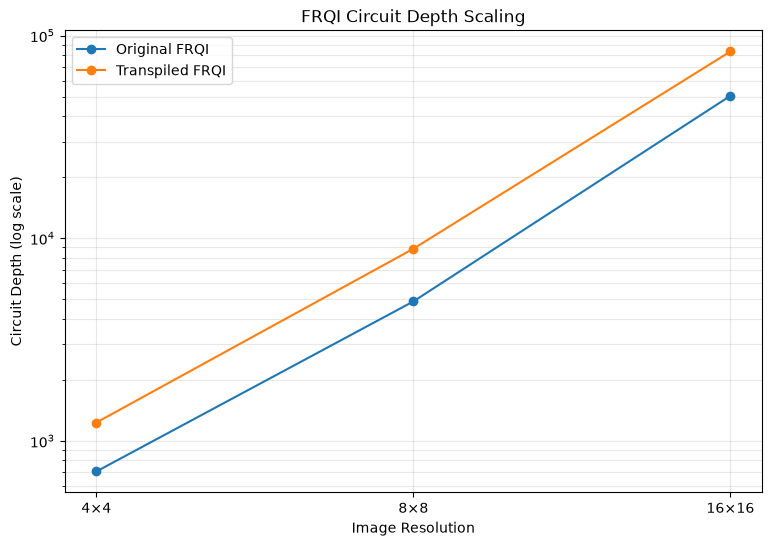

In [96]:
plt.figure(figsize=(9, 6))

plt.plot(
    resolutions,
    original_depth,
    marker="o",
    label="Original FRQI"
)

plt.plot(
    resolutions,
    transpiled_depth,
    marker="o",
    label="Transpiled FRQI"
)

plt.yscale("log")

plt.xlabel("Image Resolution")
plt.ylabel("Circuit Depth (log scale)")
plt.title("FRQI Circuit Depth Scaling")
plt.legend()
plt.grid(True, which="both", alpha=0.3)

plt.show()

## Results and Analysis

The experiments demonstrate a rapid increase in FRQI circuit complexity as the image resolution increases.

The number of pixels increases from 16 for a 4×4 image to 64 for an 8×8 image and 256 for a 16×16 image. However, the corresponding number of qubits increases only from 5 to 7 to 9 because the FRQI position register requires logarithmic growth in the number of qubits.

Despite this compact qubit representation, the circuit depth increases substantially. The original FRQI circuit depth increases from 706 for 4×4 images to 4,875 for 8×8 images and 50,435 for 16×16 images. The number of CX gates similarly increases from 384 to 3,584 and 26,624.

This demonstrates an important trade-off in FRQI: although image information can be represented using relatively few qubits, the gate complexity required to encode the pixel intensities grows rapidly with image resolution.

Hardware-aware transpilation further increases the circuit cost. Using the same FakeGuadalupeV2 backend for all three resolutions, the depth overhead is 74.36%, 81.93%, and 65.46% for 4×4, 8×8, and 16×16 respectively. The corresponding CX-gate overhead is 66.41%, 74.02%, and 75.97%.

The results therefore indicate that the primary scalability limitation of this FRQI implementation is not the number of qubits, but the rapidly increasing circuit depth and two-qubit gate requirements.

## Image Reconstruction Quality

The 8×8 MNIST image was reconstructed from the ideal FRQI statevector to evaluate the correctness of the encoding and decoding process.

The reconstruction produced an MSE of approximately 1.987 × 10⁻²⁴ and a PSNR of approximately 285.15 dB. The MSE is effectively zero, indicating that the reconstructed image is numerically almost identical to the original image under ideal statevector simulation.

The extremely high PSNR is expected because the statevector simulation provides direct access to the ideal quantum amplitudes without hardware noise or finite-shot sampling. Therefore, this result demonstrates the correctness of the FRQI encoding/reconstruction implementation rather than the performance of FRQI under realistic noisy quantum hardware.

# Conclusion

This experiment investigated the use of Flexible Representation of Quantum Images (FRQI) for encoding MNIST images at 4×4, 8×8, and 16×16 resolutions.

The results show that FRQI provides a compact qubit representation. The total number of qubits increases from 5 to 7 to 9 as the image resolution increases from 4×4 to 8×8 and 16×16.

However, this qubit efficiency comes at the cost of rapidly increasing circuit complexity. The original circuit depth increases from 706 to 4,875 and then to 50,435, while the number of CX gates increases from 384 to 3,584 and then to 26,624.

Hardware-aware transpilation using a common FakeGuadalupeV2 backend introduces additional overhead, with depth overhead ranging from 65.46% to 81.93% and CX overhead ranging from 66.41% to 75.97%.

The ideal statevector reconstruction of the 8×8 MNIST image produced an almost zero MSE and a PSNR of approximately 285.15 dB, confirming the correctness of the implemented FRQI encoding and reconstruction procedure.

Overall, the experiment demonstrates that while FRQI offers significant qubit efficiency for image representation, its gate count and circuit depth can become a major scalability limitation as image resolution increases. This highlights the importance of investigating more efficient quantum image representation and encoding techniques for larger images.